# Практическая работа №4. Регрессионная модель

## Цель работы

Построить и интерпретировать модель линейной регрессии, корректно оценив её качество.

В работе используется датасет Abalone.

Целевая переменная — `Rings`.

В работе сравниваются модели на полном и сокращённом наборе признаков.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.stats.outliers_influence import variance_inflation_factor

## 1. Загрузка и первичный просмотр данных

Загрузим датасет и проверим его структуру.

In [3]:
df = pd.read_csv("../data/abalone.data.csv")

print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
display(df.head())

Размер датасета: (4177, 9)

Первые 5 строк:


,gender,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


## 2. Разделение признаков и целевой переменной

Целевой переменной является `Rings`.

Остальные столбцы используются как признаки для построения модели.

In [4]:
X = df.drop(columns=["Rings"])
y = df["Rings"]

print("Признаки:")
print(X.columns.tolist())

print("\nЦелевая переменная:")
print(y.name)

Признаки:
['gender', 'Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight', 'Viscera weight', 'Shell weight']

Целевая переменная:
Rings


In [5]:
numeric_features = [
    "Length",
    "Diameter",
    "Height",
    "Whole weight",
    "Shucked weight",
    "Viscera weight",
    "Shell weight"
]

categorical_features = ["gender"]

print("Числовые признаки:")
print(numeric_features)

print("\nКатегориальные признаки:")
print(categorical_features)

Числовые признаки:
['Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight', 'Viscera weight', 'Shell weight']

Категориальные признаки:
['gender']


## 3. Разделение данных на обучающую и тестовую выборки

Сначала разделим данные на обучающую и тестовую выборки.

Предобработка будет обучаться только на тренировочных данных, чтобы избежать утечки данных.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Размер X_train:", X_train.shape)
print("Размер X_test:", X_test.shape)
print("Размер y_train:", y_train.shape)
print("Размер y_test:", y_test.shape)

Размер X_train: (3341, 8)
Размер X_test: (836, 8)
Размер y_train: (3341,)
Размер y_test: (836,)


## 4. Предобработка признаков

Используем pipeline из практической работы №3.

Для числовых признаков:
- пропуски заменяются медианой;
- выполняется стандартизация.

Для категориального признака:
- пропуски заменяются отдельной категорией;
- выполняется One-Hot Encoding.

In [7]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 5. Базовая модель линейной регрессии

Сначала обучим базовую модель, используя все доступные признаки.

Это позволит получить исходные значения метрик, с которыми затем будет сравниваться модель на сокращённом наборе признаков.

In [8]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)

print("Первые 10 предсказаний:")
print(y_pred_baseline[:10])

Первые 10 предсказаний:
[11.76136132 10.24192648 14.00103561 11.99509311 11.16141477 10.23009202
  9.417632    9.14955846  7.1918906  10.80525772]


## 6. Оценка качества базовой модели

Для оценки модели используем MAE, MSE, RMSE и R².

MAE и RMSE показывают среднюю ошибку в единицах целевой переменной `Rings`.

R² показывает, какую долю вариации целевой переменной объясняет модель.

In [9]:
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
mse_baseline = mean_squared_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mse_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)

print("Базовая модель:")
print(f"MAE  = {mae_baseline:.3f}")
print(f"MSE  = {mse_baseline:.3f}")
print(f"RMSE = {rmse_baseline:.3f}")
print(f"R²   = {r2_baseline:.3f}")

Базовая модель:
MAE  = 1.593
MSE  = 4.891
RMSE = 2.212
R²   = 0.548


## 7. Проверка мультиколлинеарности

Проверим корреляции между числовыми признаками.

Сильная корреляция между признаками может указывать на мультиколлинеарность и наличие избыточной информации.

In [10]:
correlation_matrix = df[numeric_features].corr()

display(correlation_matrix.round(3))

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight
Length,1.000,0.987,0.828,0.925,0.898,0.903,0.898
Diameter,0.987,1.000,0.834,0.925,0.893,0.900,0.905
Height,0.828,0.834,1.000,0.819,0.775,0.798,0.817
Whole weight,0.925,0.925,0.819,1.000,0.969,0.966,0.955
Shucked weight,0.898,0.893,0.775,0.969,1.000,0.932,0.883
Viscera weight,0.903,0.900,0.798,0.966,0.932,1.000,0.908
Shell weight,0.898,0.905,0.817,0.955,0.883,0.908,1.000


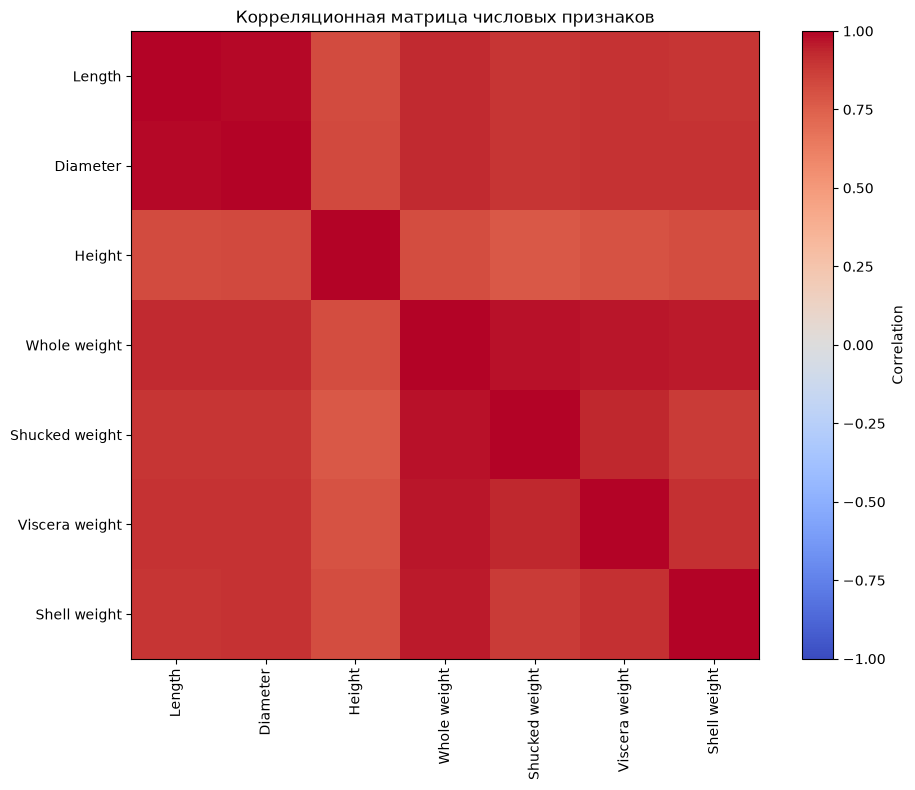

In [11]:
plt.figure(figsize=(10, 8))

plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Корреляционная матрица числовых признаков")

plt.tight_layout()
plt.show()

### Проверка VIF

VIF показывает, насколько один признак может быть объяснён другими признаками.

Большие значения VIF указывают на возможную мультиколлинеарность.

In [12]:
X_vif = df[numeric_features].copy()

vif_data = pd.DataFrame()

vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

display(vif_data.sort_values("VIF", ascending=False).round(2))

,Feature,VIF
3,Whole weight,109.59
1,Diameter,41.85
0,Length,40.77
4,Shucked weight,28.35
6,Shell weight,21.26
5,Viscera weight,17.35
2,Height,3.56


## 8. Формирование сокращённого набора признаков

На основе анализа корреляций и VIF удалим наиболее избыточные числовые признаки.

Будем последовательно удалять признак с наибольшим VIF, пока значения VIF не станут ниже выбранного порога.

In [13]:
reduced_numeric_features = numeric_features.copy()

while True:
    X_vif = df[reduced_numeric_features].copy()

    vif_values = pd.Series(
        [
            variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])
        ],
        index=reduced_numeric_features
    )

    max_vif = vif_values.max()

    if max_vif <= 10 or len(reduced_numeric_features) <= 2:
        break

    feature_to_remove = vif_values.idxmax()

    print(
        f"Удаляем: {feature_to_remove}, "
        f"VIF = {max_vif:.2f}"
    )

    reduced_numeric_features.remove(feature_to_remove)

print("\nФинальный сокращённый набор:")
print(reduced_numeric_features)

Удаляем: Whole weight, VIF = 109.59
Удаляем: Diameter, VIF = 41.82
Удаляем: Viscera weight, VIF = 10.69

Финальный сокращённый набор:
['Length', 'Height', 'Shucked weight', 'Shell weight']


## 9. Обучение модели на сокращённом наборе признаков

Создадим второй preprocessing pipeline, используя только выбранные признаки.

In [14]:
X_train_reduced = X_train[reduced_numeric_features + categorical_features]
X_test_reduced = X_test[reduced_numeric_features + categorical_features]

reduced_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

reduced_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

reduced_preprocessor = ColumnTransformer(
    transformers=[
        ("num", reduced_numeric_transformer, reduced_numeric_features),
        ("cat", reduced_categorical_transformer, categorical_features)
    ]
)

## 10. Сокращённая модель линейной регрессии

Обучим вторую модель на сокращённом наборе признаков и сравним её с базовой моделью.

In [15]:
reduced_model = Pipeline(steps=[
    ("preprocessor", reduced_preprocessor),
    ("regressor", LinearRegression())
])

reduced_model.fit(X_train_reduced, y_train)

y_pred_reduced = reduced_model.predict(X_test_reduced)

In [16]:
mae_reduced = mean_absolute_error(y_test, y_pred_reduced)
mse_reduced = mean_squared_error(y_test, y_pred_reduced)
rmse_reduced = np.sqrt(mse_reduced)
r2_reduced = r2_score(y_test, y_pred_reduced)

print("Сокращённая модель:")
print(f"MAE  = {mae_reduced:.3f}")
print(f"MSE  = {mse_reduced:.3f}")
print(f"RMSE = {rmse_reduced:.3f}")
print(f"R²   = {r2_reduced:.3f}")

Сокращённая модель:
MAE  = 1.643
MSE  = 5.197
RMSE = 2.280
R²   = 0.520


## 11. Сравнение моделей

Сравним качество базовой модели со всеми признаками и модели на сокращённом наборе признаков.

In [17]:
comparison = pd.DataFrame({
    "Model": [
        "Базовая модель",
        "Сокращённая модель"
    ],
    "MAE": [
        mae_baseline,
        mae_reduced
    ],
    "MSE": [
        mse_baseline,
        mse_reduced
    ],
    "RMSE": [
        rmse_baseline,
        rmse_reduced
    ],
    "R2": [
        r2_baseline,
        r2_reduced
    ]
})

display(comparison.round(3))

,Model,MAE,MSE,RMSE,R2
0,Базовая модель,1.593,4.891,2.212,0.548
1,Сокращённая модель,1.643,5.197,2.280,0.520


## 12. График предсказанных и истинных значений

Построим график, на котором сравним реальные значения `Rings` с предсказаниями модели.

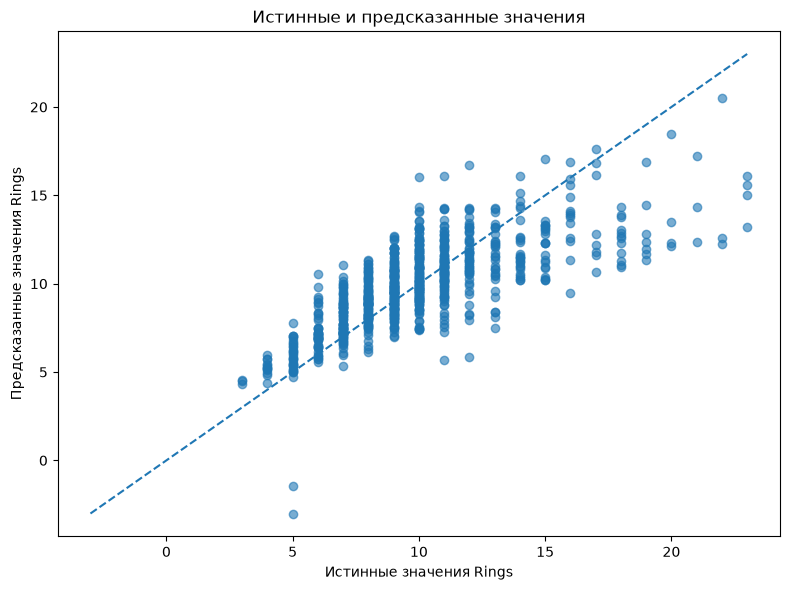

In [18]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_baseline, alpha=0.6)

min_value = min(y_test.min(), y_pred_baseline.min())
max_value = max(y_test.max(), y_pred_baseline.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Истинные значения Rings")
plt.ylabel("Предсказанные значения Rings")
plt.title("Истинные и предсказанные значения")

plt.tight_layout()
plt.show()

## 13. Анализ остатков

Остаток определяется как разница между истинным и предсказанным значением:

`residual = y_true - y_pred`.

Проверим, присутствует ли в остатках систематический паттерн.

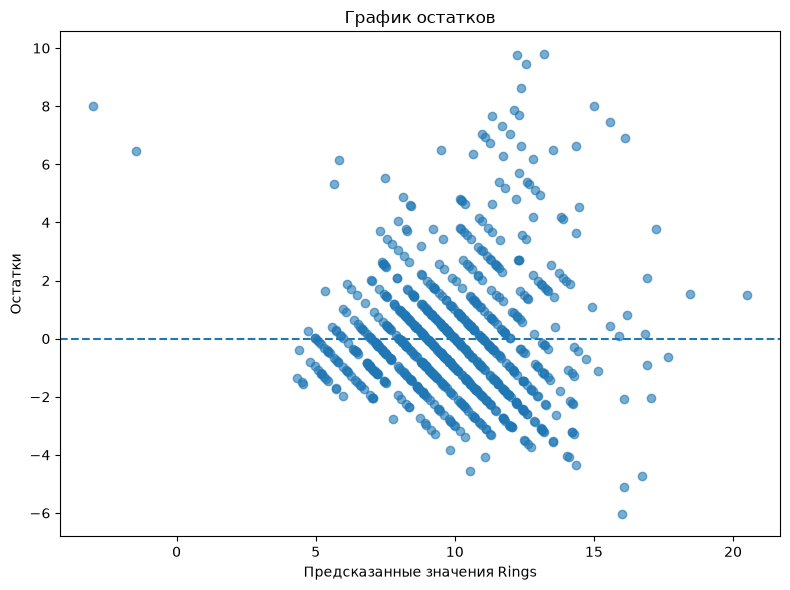

In [19]:
residuals = y_test - y_pred_baseline

plt.figure(figsize=(8, 6))

plt.scatter(y_pred_baseline, residuals, alpha=0.6)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Предсказанные значения Rings")
plt.ylabel("Остатки")
plt.title("График остатков")

plt.tight_layout()
plt.show()

In [20]:
print("Средний остаток:", residuals.mean())
print("Стандартное отклонение остатков:", residuals.std())

Средний остаток: -0.009064720393039807
Стандартное отклонение остатков: 2.212918422124127


## Вывод

В работе была построена базовая модель линейной регрессии на всех доступных признаках датасета Abalone.

Качество базовой модели составило: MAE = 1.593, RMSE = 2.212 и R² = 0.548. Это означает, что в среднем модель ошибается примерно на 1.59 кольца, а модель объясняет около 54.8% вариации целевой переменной `Rings`.

Проверка корреляционной матрицы и VIF показала наличие сильной мультиколлинеарности между числовыми признаками. Например, корреляция между `Length` и `Diameter` составила около 0.987, а VIF для `Whole weight` достиг 109.59.

На основании VIF были удалены признаки `Whole weight`, `Diameter` и `Viscera weight`. В сокращённой модели остались признаки `Length`, `Height`, `Shucked weight` и `Shell weight`.

После сокращения набора признаков MAE увеличилась с 1.593 до 1.643, RMSE увеличилась с 2.212 до 2.280, а R² уменьшился с 0.548 до 0.520. Следовательно, удаление признаков привело к небольшому снижению качества модели.

Таким образом, сокращённая модель уменьшает количество числовых признаков и снижает влияние мультиколлинеарности, но при этом теряет часть полезной информации. Поэтому по качеству предсказания базовая модель с полным набором признаков показывает более высокие значения метрик на тестовой выборке.